In [28]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


# Example usage: load a .mat file
# Provide the path to your .mat data file



In [29]:
name1 = 'CT'
name2 = 'T3D3'
exp = str(1)

u_CT = scipy.io.loadmat(name1+'_u_'+exp+'.mat')["u"]
y_CT = scipy.io.loadmat(name1+'_x_'+exp+'.mat')["y"]



u_sp_CT = scipy.io.loadmat(name1+'_u_sp_'+exp+'.mat')["u_sp"]
y_sp_CT = scipy.io.loadmat(name1+'_y_sp_'+exp+'.mat')["y_sp"]

exp = str(1)
u_T2D2 = scipy.io.loadmat(name2+'_u_'+exp+'.mat')["u"]
y_T2D2 = scipy.io.loadmat(name2+'_x_'+exp+'.mat')["y"]

u_sp_T2D2 = scipy.io.loadmat(name2+'_u_sp_'+exp+'.mat')["u_sp"]
y_sp_T2D2 = scipy.io.loadmat(name2+'_y_sp_'+exp+'.mat')["y_sp"]



In [30]:
u_T2D2.shape

(500, 2)

In [31]:
# u_sp_CT = scipy.io.loadmat('CT_u_sp_7.mat')["u_sp"]
# y_sp_CT = scipy.io.loadmat('CT_y_sp_7.mat')["y_sp"]


# u_sp_T2D2 = scipy.io.loadmat('T2D2_u_sp_7.mat')["u_sp"]
# y_sp_T2D2 = scipy.io.loadmat('T2D2_y_sp_7.mat')["y_sp"]


In [32]:
# Sum of the two retained inputs (columns 1 and 2 of raw MAT; column 0 omitted)
u_CT[:, 1:].sum(axis=0)


array([9599.46077313])

In [33]:
u_T2D2[:, 1:].sum(axis=0)


array([10195.19754446])

CT tracking (Qy):           318.054
CT u vs target (Qu):        47.113
CT delta-u (Qdu):           13.757
CT total:                   378.924
T2D2 tracking (Qy):         470.661
T2D2 u vs target (Qu):      108.289
T2D2 delta-u (Qdu):        34.277
T2D2 total:                 613.227


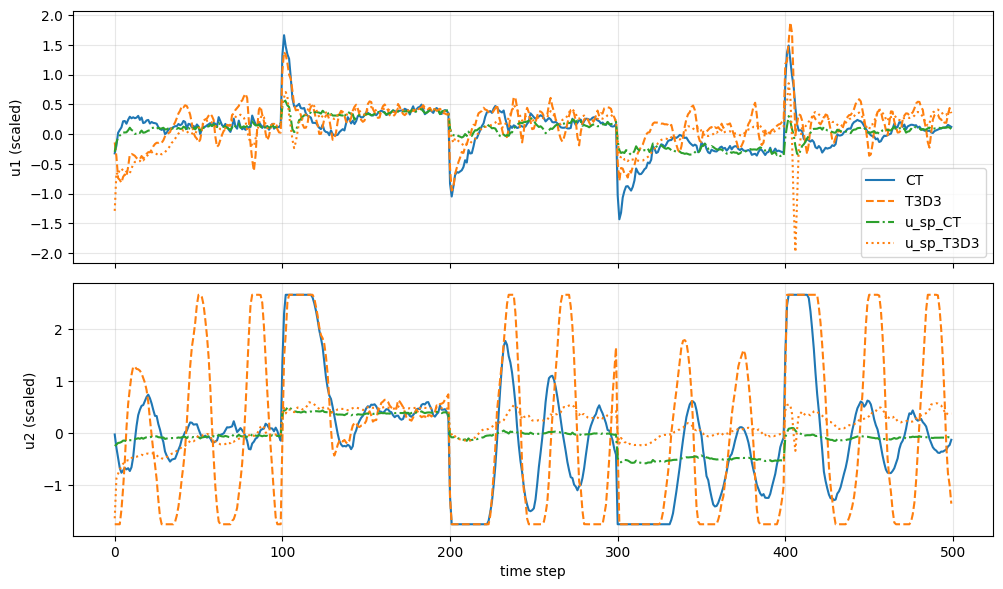

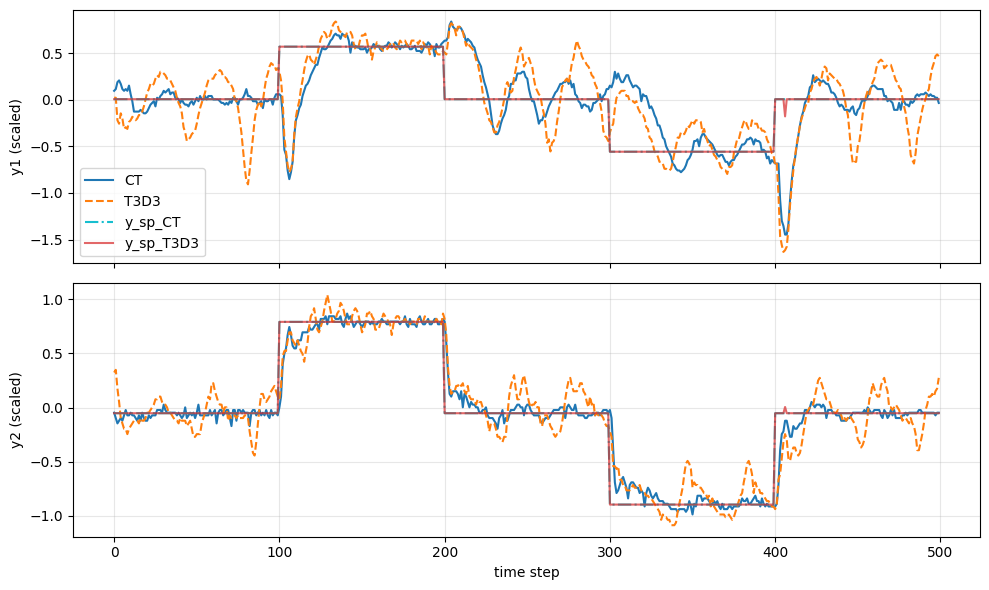

In [34]:
# Load MPC setup (scaled references, weights, etc.)
sim_setup = joblib.load(os.path.join('..', 'sim_setup.pkl'))
ref_scaled = sim_setup['reference']  # shape (ny, sim_time)
Qy = sim_setup['Qy']
Qu = sim_setup['Qu']
Qdu = sim_setup['Qdu']

# Also load scalers explicitly in case data here is non-scaled
scaler = joblib.load(os.path.join('..', '..', 'data', 'scaler.pkl'))
scalerU = joblib.load(os.path.join('..', '..', 'data', 'scalerU.pkl'))


def to_time_first(arr):
    """Return array as shape (T, n_ch) with time in rows."""
    a = np.squeeze(arr)
    if a.ndim == 1:
        a = a[:, None]
    if a.ndim != 2:
        raise ValueError('expected a 2D array')
    # Typical export: (n_ch, T) with T >> n_ch
    if a.shape[0] <= 4 and a.shape[1] > a.shape[0]:
        a = a.T
    return a


# Put signals into (T, n_ch)
u_CT_t = to_time_first(u_CT)
y_CT_t = to_time_first(y_CT)

u_T2D2_t = to_time_first(u_T2D2)
y_T2D2_t = to_time_first(y_T2D2)

# Also put setpoints into (T, n_ch), using "sp" variables loaded elsewhere in notebook
u_sp_CT_t = to_time_first(u_sp_CT)
y_sp_CT_t = to_time_first(y_sp_CT)

u_sp_T2D2_t = to_time_first(u_sp_T2D2)
y_sp_T2D2_t = to_time_first(y_sp_T2D2)

# PU2x2 (2x2): if logs still include the original first input/output, drop them
if u_CT_t.shape[1] > 2:
    u_CT_t = u_CT_t[:, 1:]
    u_T2D2_t = u_T2D2_t[:, 1:]
    u_sp_CT_t = u_sp_CT_t[:, 1:]
    u_sp_T2D2_t = u_sp_T2D2_t[:, 1:]
if y_CT_t.shape[1] > 2:
    y_CT_t = y_CT_t[:, 1:]
    y_T2D2_t = y_T2D2_t[:, 1:]
    y_sp_CT_t = y_sp_CT_t[:, 1:]
    y_sp_T2D2_t = y_sp_T2D2_t[:, 1:]

if ref_scaled.shape[0] > 2:
    ref_scaled = ref_scaled[1:, :]
if Qy.shape[0] > 2:
    Qy = Qy[1:, 1:]
if Qu.shape[0] > 2:
    Qu = Qu[1:, 1:]
if Qdu.shape[0] > 2:
    Qdu = Qdu[1:, 1:]

# Scale data (if already scaled this is a no-op modulo affine transform consistent with setup)
u_CT_scaled = scalerU.transform(u_CT_t)
y_CT_scaled = scaler.transform(y_CT_t)

u_T2D2_scaled = scalerU.transform(u_T2D2_t)
y_T2D2_scaled = scaler.transform(y_T2D2_t)

u_sp_CT_scaled = scalerU.transform(u_sp_CT_t)
y_sp_CT_scaled = scaler.transform(y_sp_CT_t)

u_sp_T2D2_scaled = scalerU.transform(u_sp_T2D2_t)
y_sp_T2D2_scaled = scaler.transform(y_sp_T2D2_t)

# Truncate to common simulation horizon (align u, y, ref, and logged target input u_sp)
T_CT = min(
    y_CT_scaled.shape[0],
    ref_scaled.shape[1],
    y_sp_CT_scaled.shape[0],
    u_sp_CT_scaled.shape[0],
    u_CT_scaled.shape[0],
)
T_T2D2 = min(
    y_T2D2_scaled.shape[0],
    ref_scaled.shape[1],
    y_sp_T2D2_scaled.shape[0],
    u_sp_T2D2_scaled.shape[0],
    u_T2D2_scaled.shape[0],
)
T_spu_CT = min(u_sp_CT_scaled.shape[0], ref_scaled.shape[1])
T_spu_T2D2 = min(u_sp_T2D2_scaled.shape[0], ref_scaled.shape[1])

# Closed-loop objective (scaled space), matching MPC: Qy on y tracking, Qu on (u_target - u),
# Qdu on (u[k] - u[k-1]). Logged u_sp is the target steady-state input from target estimation.
J_CT_tracking = 0.0
J_CT_u_target = 0.0
J_CT_du = 0.0
for k in range(50, T_CT):
    e_y = y_CT_scaled[k] - ref_scaled[:, k]
    e_u_tgt = u_sp_CT_scaled[k] - u_CT_scaled[k]
    du = u_CT_scaled[k] - u_CT_scaled[k - 1]
    J_CT_tracking += e_y @ Qy @ e_y
    J_CT_u_target += e_u_tgt @ Qu @ e_u_tgt
    J_CT_du += du @ Qdu @ du
J_CT_sum = J_CT_tracking + J_CT_u_target + J_CT_du

J_T2D2_tracking = 0.0
J_T2D2_u_target = 0.0
J_T2D2_du = 0.0
for k in range(50, T_T2D2):
    e_y = y_T2D2_scaled[k] - ref_scaled[:, k]
    e_u_tgt = u_sp_T2D2_scaled[k] - u_T2D2_scaled[k]
    du = u_T2D2_scaled[k] - u_T2D2_scaled[k - 1]
    J_T2D2_tracking += e_y @ Qy @ e_y
    J_T2D2_u_target += e_u_tgt @ Qu @ e_u_tgt
    J_T2D2_du += du @ Qdu @ du
J_T2D2_sum = J_T2D2_tracking + J_T2D2_u_target + J_T2D2_du

print(f"CT tracking (Qy):           {J_CT_tracking:.3f}")
print(f"CT u vs target (Qu):        {J_CT_u_target:.3f}")
print(f"CT delta-u (Qdu):           {J_CT_du:.3f}")
print(f"CT total:                   {J_CT_sum:.3f}")

print(f"T2D2 tracking (Qy):         {J_T2D2_tracking:.3f}")
print(f"T2D2 u vs target (Qu):      {J_T2D2_u_target:.3f}")
print(f"T2D2 delta-u (Qdu):        {J_T2D2_du:.3f}")
print(f"T2D2 total:                 {J_T2D2_sum:.3f}")

# Time vectors
t_CT = np.arange(u_CT_t.shape[0])
t_T2D2 = np.arange(u_T2D2_t.shape[0])
t_ref = np.arange(ref_scaled.shape[1])
t_spy_CT = np.arange(T_CT)
t_spy_T2D2 = np.arange(T_T2D2)
t_spu_CT = np.arange(T_spu_CT)
t_spu_T2D2 = np.arange(T_spu_T2D2)

# Plot inputs u (2 dimensions), with u_sp for both CT and T2D2
fig_u, axes_u = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i in range(2):
    axes_u[i].plot(t_CT, u_CT_scaled[:, i], label=name1, linestyle='-')
    axes_u[i].plot(t_T2D2, u_T2D2_scaled[:, i], label=name2, linestyle='--')
    axes_u[i].plot(t_spu_CT, u_sp_CT_scaled[:T_spu_CT, i], label='u_sp_' + name1, linestyle='-.', color='tab:green')
    axes_u[i].plot(t_spu_T2D2, u_sp_T2D2_scaled[:T_spu_T2D2, i], label='u_sp_' + name2, linestyle=':', color='tab:orange')
    axes_u[i].set_ylabel(f'u{i + 1} (scaled)')
    axes_u[i].grid(True, alpha=0.3)
axes_u[-1].set_xlabel('time step')
axes_u[0].legend(loc='best')
fig_u.tight_layout()

# Plot outputs y (2 dimensions) with references from setup and y_sp for both CT and T2D2
fig_y, axes_y = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i in range(2):
    axes_y[i].plot(t_CT, y_CT_scaled[:, i], label=name1, linestyle='-')
    axes_y[i].plot(t_T2D2, y_T2D2_scaled[:, i], label=name2, linestyle='--')
    axes_y[i].plot(t_spy_CT, y_sp_CT_scaled[:T_CT, i], label='y_sp_' + name1, linestyle='-.', color='tab:cyan')
    axes_y[i].plot(t_spy_T2D2, y_sp_T2D2_scaled[:T_T2D2, i], label='y_sp_' + name2, linestyle='-', color='tab:red', alpha=0.7)
    axes_y[i].set_ylabel(f'y{i + 1} (scaled)')
    axes_y[i].grid(True, alpha=0.3)
axes_y[-1].set_xlabel('time step')
axes_y[0].legend(loc='best')
fig_y.tight_layout()


In [35]:
# Mismatch: first retained output vs reference (run analysis cell first so ref_scaled is 2-row)
np.sum(np.square(y_T2D2_scaled[300:, 0] - ref_scaled[0, 300:]))


np.float64(37.520725589666604)

In [36]:
np.sum(np.square(y_CT_scaled[300:, 0] - ref_scaled[0, 300:]))


np.float64(30.926326341749988)